In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tanushkumaryadav/hhhhh/check_hh.csv


In [3]:
df=pd.read_csv("/kaggle/input/datasets/tanushkumaryadav/hhhhh/check_hh.csv")

In [4]:
df.sample(10)

,formula,choice
532,Ge1Tc1Zr1,0
192,CoTiAs,1
1035,Mn1Ta1Y1,0
990,Ga1Sn1V1,0
931,Br1Cl1Nb1,0
140,RuVAl,1
859,Nb1P1Sr1,0
647,In1Pt1W1,0
1062,Sn1Tc1Zn1,0
1135,Br1Ni1Zr1,0


In [5]:
!pip install pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 15.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 71.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 82.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 90.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.9 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=750c802667649f2fa3e6bf912ed61dd7d3e4ab0465620f

In [99]:
from pymatgen.core import Composition
c=Composition("Al3Ag2As1")
d=Composition("AlAgAs")
cc=list(c.get_el_amt_dict().keys())
ccc=list(c.get_el_amt_dict().values())
print(sorted(c.values()))
print(sorted(d.values()))
print(cc)
print(ccc)

[1.0, 2.0, 3.0]
[1.0, 1.0, 1.0]
['Al', 'Ag', 'As']
[3.0, 2.0, 1.0]


In [22]:
from pymatgen.core import Composition, Element
def parse_mol(formula):
    com=Composition(formula)
    elements = list(com.get_el_amt_dict().keys())
    amounts = list(com.get_el_amt_dict().values())
    X=[Element(elements[0]).X,Element(elements[1]).X, Element(elements[2]).X]
    c, b, a = sorted(X)
    A = elements[X.index(a)]
    B=elements[X.index(b)]
    C=elements[X.index(c)]
    return A,B,C

parse_mol("CoTiSn")
    

('Sn', 'Co', 'Ti')

In [7]:
from pymatgen.core import Element

el = Element("Li")

print(el.group)
print(el.row)
print(el.X)                 # Pauling electronegativity
print(el.atomic_mass)
print(el.atomic_radius)
print(el.full_electronic_structure)

1
2
0.98
6.941 amu
1.45 ang
[(1, 's', 2), (2, 's', 1)]


In [10]:
df_filtered = df.iloc[valid_indices].reset_index(drop=True)

print(df_filtered.shape)

print(df_filtered['label'].value_counts())

(2211, 2)
label
0    1761
1     450
Name: count, dtype: int64


In [61]:
descriptors = {'t_s': [], 't_p': [], 't_d': [], 't_all': [],'r_AB': [], 'r_AC': [],'r_BC': [], 'en_A': [], 'en_B': [], 'en_C': [],'g_A': [], 
               'g_B': [], 'g_C': [], 'r_A': [], 'r_B': [], 'r_C': [],'m_A': [], 'm_B': [], 'm_C': [],
                'p_A': [], 'p_B': [], 'p_C': []}
def Descriptors(A,B,C):
    el_A=Element(A)
    el_B=Element(B)
    el_C=Element(C)
    q_s,q_p,q_d=0,0,0
    for atom,mul in [(A,1),(B,1),(C,1)]:
        el=Element(atom)
        structure=el.full_electronic_structure
        n_max = max(n for n, l, q in structure)
        for n,l,q in el.full_electronic_structure:
            if(l=='s' and n==n_max):
                q_s+=mul*q
            if(l=='p' and n==n_max):
                q_p+=mul*q
            if(l=='d' and n==n_max-1 and el.group <= 12):
                q_d+=mul*q
    descriptors['t_s'].append(q_s)
    descriptors['t_p'].append(q_p)
    descriptors['t_d'].append(q_d)
    descriptors['t_all'].append(q_s+q_p+q_d)
    R_AB=abs(el_A.atomic_radius-el_B.atomic_radius)
    descriptors['r_AB'].append(R_AB)
    descriptors['en_B'].append(el_B.X)
    descriptors['en_C'].append(el_C.X)
    descriptors['en_A'].append(el_A.X)
    descriptors['g_A'].append(el_A.group)
    descriptors['g_B'].append(el_B.group)
    descriptors['g_C'].append(el_C.group)
    R_AC=abs(el_A.atomic_radius-el_C.atomic_radius)
    descriptors['r_AC'].append(R_AC)
    R_BC=abs(el_B.atomic_radius-el_C.atomic_radius)
    descriptors['r_BC'].append(R_BC)
    descriptors['r_C'].append(el_C.atomic_radius)
    descriptors['r_B'].append(el_B.atomic_radius)
    descriptors['r_A'].append(el_A.atomic_radius)
    descriptors['m_C'].append(el_C.atomic_mass)
    descriptors['m_B'].append(el_B.atomic_mass)
    descriptors['m_A'].append(el_A.atomic_mass)
    descriptors['p_A'].append(el_A.row)
    descriptors['p_B'].append(el_B.row)
    descriptors['p_C'].append(el_C.row)
    


In [62]:
for formula in df['formula']:
    A,B,C=parse_mol(formula)
    Descriptors(A,B,C)

In [63]:
len(descriptors['t_s'])

1212

In [64]:
descriptor_df = pd.DataFrame(descriptors)

In [65]:
descriptor_df.shape

(1212, 22)

In [66]:
descriptor_df.isnull().sum()

t_s      0
t_p      0
t_d      0
t_all    0
r_AB     0
r_AC     0
r_BC     0
en_A     0
en_B     0
en_C     0
g_A      0
g_B      0
g_C      0
r_A      0
r_B      0
r_C      0
m_A      0
m_B      0
m_C      0
p_A      0
p_B      0
p_C      0
dtype: int64

In [67]:
descriptor_df.head()

,t_s,t_p,t_d,t_all,r_AB,r_AC,r_BC,en_A,en_B,en_C,...,g_C,r_A,r_B,r_C,m_A,m_B,m_C,p_A,p_B,p_C
0,5,1,7,13,0.10,0.10,0.0,1.81,1.66,1.54,...,4,1.30,1.4,1.4,69.7230,51.9961,47.867,4,4,4
1,5,1,7,13,0.15,0.15,0.0,1.78,1.66,1.54,...,4,1.55,1.4,1.4,114.8180,51.9961,47.867,5,4,4
2,5,2,7,14,0.30,0.30,0.0,1.90,1.66,1.54,...,4,1.10,1.4,1.4,28.0855,51.9961,47.867,3,4,4
3,5,2,7,14,0.15,0.15,0.0,2.01,1.66,1.54,...,4,1.25,1.4,1.4,72.6400,51.9961,47.867,4,4,4
4,5,2,7,14,0.05,0.05,0.0,1.96,1.66,1.54,...,4,1.45,1.4,1.4,118.7100,51.9961,47.867,5,4,4


In [68]:
df_final = pd.concat([df.reset_index(drop=True),descriptor_df.reset_index(drop=True)],axis=1)

In [69]:
df_final.head()

,formula,choice,t_s,t_p,t_d,t_all,r_AB,r_AC,r_BC,en_A,...,g_C,r_A,r_B,r_C,m_A,m_B,m_C,p_A,p_B,p_C
0,CrTiGa,1,5,1,7,13,0.10,0.10,0.0,1.81,...,4,1.30,1.4,1.4,69.7230,51.9961,47.867,4,4,4
1,CrTiIn,1,5,1,7,13,0.15,0.15,0.0,1.78,...,4,1.55,1.4,1.4,114.8180,51.9961,47.867,5,4,4
2,CrTiSi,1,5,2,7,14,0.30,0.30,0.0,1.90,...,4,1.10,1.4,1.4,28.0855,51.9961,47.867,3,4,4
3,CrTiGe,1,5,2,7,14,0.15,0.15,0.0,2.01,...,4,1.25,1.4,1.4,72.6400,51.9961,47.867,4,4,4
4,CrTiSn,1,5,2,7,14,0.05,0.05,0.0,1.96,...,4,1.45,1.4,1.4,118.7100,51.9961,47.867,5,4,4


In [71]:
df_final.to_csv('With_descriptors.csv',index=False)

In [23]:
from sklearn.utils import resample

positive = df_final[df_final.label == 1]
negative = df_final[df_final.label == 0]

negative_down = resample(
    negative,
    replace=False,
    n_samples=len(positive),
    random_state=42
)

df_balanced = pd.concat([positive, negative_down])

In [72]:
X = df_final.drop(columns=['formula', 'choice'])
y = df_final['choice']

In [73]:
print(X.shape)
print(y.shape)

(1212, 22)
(1212,)


In [74]:

print(y.value_counts())

print(y.value_counts(normalize=True))

choice
0    877
1    335
Name: count, dtype: int64
choice
0    0.723597
1    0.276403
Name: proportion, dtype: float64


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [76]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {'n_estimators': [200, 500, 1000],'max_depth': [5, 10, 15, 20, None],'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2'],'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=50,scoring='recall',cv=5,n_jobs=-1,random_state=42)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


In [77]:
best_params = search.best_params_
print(best_params)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


In [78]:
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score)

rf_best = RandomForestClassifier(**best_params,random_state=42,n_jobs=-1)

rf_best.fit(X_train, y_train)

prob = rf_best.predict_proba(X_test)[:,1]

for t in [0.2,0.3,0.4,0.5]:
    y_pred = (prob > t).astype(int)

    print(classification_report(y_test, y_pred))
    
    print(confusion_matrix(y_test, y_pred))
    
    print(roc_auc_score(y_test,rf_best.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       176
           1       0.81      1.00      0.89        67

    accuracy                           0.93       243
   macro avg       0.90      0.95      0.92       243
weighted avg       0.95      0.93      0.94       243

[[160  16]
 [  0  67]]
0.9883819538670284
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       176
           1       0.84      1.00      0.91        67

    accuracy                           0.95       243
   macro avg       0.92      0.96      0.94       243
weighted avg       0.96      0.95      0.95       243

[[163  13]
 [  0  67]]
0.9883819538670284
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       176
           1       0.84      1.00      0.91        67

    accuracy                           0.95       243
   macro avg       0.92      0.96      0.94 

In [79]:
rf_best.fit(X_train,y_train)

y_pred = rf_best.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       176
           1       0.85      1.00      0.92        67

    accuracy                           0.95       243
   macro avg       0.92      0.97      0.94       243
weighted avg       0.96      0.95      0.95       243



In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_best,X,y,cv=5,scoring='f1')

print(scores)
print(scores.mean())

[0.92198582 0.91156463 0.93055556 0.91156463 0.92957746]
0.921049617529561


In [81]:
import pandas as pd

importance = pd.DataFrame({'feature': X.columns,'importance': rf_best.feature_importances_})

importance = importance.sort_values('importance',ascending=False)

print(importance.head(22))

   feature  importance
15     r_C    0.183657
1      t_p    0.112389
9     en_C    0.106274
12     g_C    0.100739
18     m_C    0.086113
16     m_A    0.084922
21     p_C    0.048068
19     p_A    0.043632
2      t_d    0.038889
5     r_AC    0.035955
17     m_B    0.035255
7     en_A    0.030485
20     p_B    0.019330
6     r_BC    0.019104
10     g_A    0.018533
3    t_all    0.013821
8     en_B    0.007995
4     r_AB    0.006448
14     r_B    0.003544
11     g_B    0.002930
13     r_A    0.001646
0      t_s    0.000273


In [ ]:
df_final.groupby('choice')['t_all'].value_counts(normalize=True)

choice  t_all
0       17       0.082098
        18       0.066135
        15       0.063854
        20       0.063854
        16       0.061574
        14       0.058153
        19       0.058153
        23       0.055872
        12       0.052452
        13       0.052452
        21       0.052452
        11       0.047891
        22       0.043330
        10       0.039909
        25       0.029647
        9        0.027366
        8        0.025086
        24       0.022805
        27       0.013683
        28       0.013683
        26       0.012543
        7        0.011403
        30       0.006842
        6        0.005701
        29       0.005701
        32       0.005701
        33       0.004561
        34       0.004561
        31       0.002281
        35       0.002281
        36       0.002281
        37       0.002281
        4        0.001140
        5        0.001140
        40       0.001140
1       18       0.161194
        19       0.149254
        17       0.13432

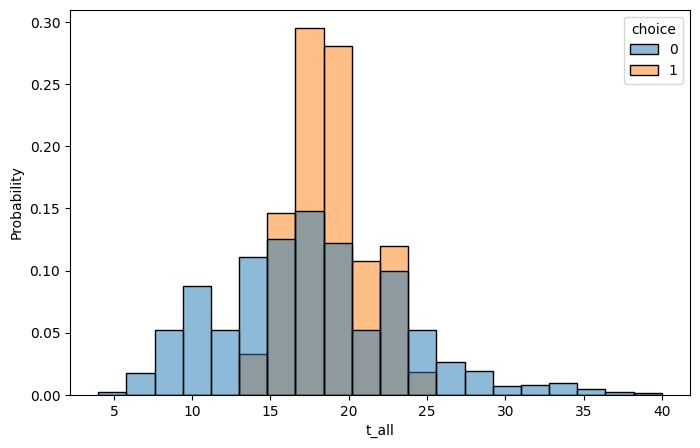

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_final,
    x='t_all',
    hue='choice',
    stat='probability',
    common_norm=False,
    bins=20
)

plt.show()

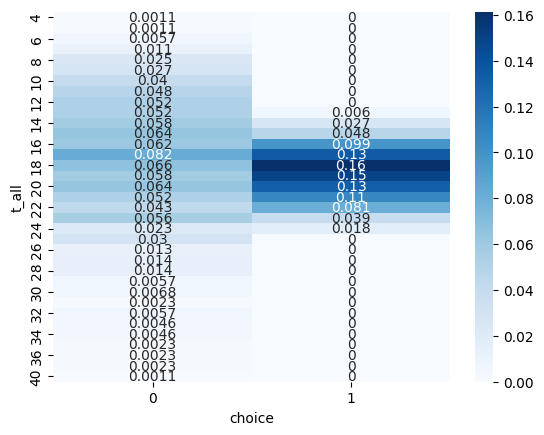

In [85]:
tab = pd.crosstab(
    df_final['t_all'],
    df_final['choice'],
    normalize='columns'
)

sns.heatmap(
    tab,
    annot=True,
    cmap='Blues'
)

plt.show()

In [60]:
df_final.sample(10)

,formula,choice,t_s,t_p,t_d,t_all,r_AB,r_AC,r_BC,en_A,...,g_C,r_A,r_B,r_C,m_A,m_B,m_C,p_A,p_B,p_C
1072,Fe1Pt1V1,0,7,0,24,31,0.05,0.00,0.05,2.28,...,5,1.35,1.40,1.35,195.084000,55.845000,50.941500,6,4,4
6,CrVAl,1,7,1,11,19,0.05,0.15,0.10,1.66,...,13,1.40,1.35,1.25,51.996100,50.941500,26.981539,4,4,3
696,La1Li1Tc1,0,7,0,7,14,0.60,0.10,0.50,1.90,...,1,1.35,1.95,1.45,98.000000,138.905470,6.941000,5,6,2
1092,Ag1Ge1Ir1,0,7,4,17,28,0.10,0.25,0.35,2.20,...,11,1.35,1.25,1.60,192.217000,72.640000,107.868200,6,4,5
325,NiMnP,1,8,3,21,32,0.35,0.40,0.05,2.19,...,7,1.00,1.35,1.40,30.973762,58.693400,54.938045,3,4,4
534,P1Zn1Zr1,0,8,3,22,33,0.35,0.55,0.20,2.19,...,4,1.00,1.35,1.55,30.973762,65.409000,91.224000,3,4,5
997,La1Li1Ta1,0,7,0,5,12,0.50,0.00,0.50,1.50,...,1,1.45,1.95,1.45,180.947880,138.905470,6.941000,6,6,2
888,Cl1Ir1Rh1,0,6,5,23,34,0.35,0.35,0.00,3.16,...,9,1.00,1.35,1.35,35.453000,102.905500,192.217000,3,5,6
1127,Cr1Sn1Y1,0,6,2,11,19,0.05,0.35,0.40,1.96,...,3,1.45,1.40,1.80,118.710000,51.996100,88.905850,5,4,5
760,B1Co1Hf1,0,8,1,16,25,0.50,0.70,0.20,2.04,...,4,0.85,1.35,1.55,10.811000,58.933195,178.490000,2,4,6


In [87]:
df_test=df_final.drop(['r_C','en_C','g_C','m_C','p_C'], axis=1)

In [88]:
X = df_test.drop(columns=['formula', 'choice'])
y = df_test['choice']

In [89]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [90]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {'n_estimators': [200, 500, 1000],'max_depth': [5, 10, 15, 20, None],'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2'],'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=50,scoring='recall',cv=5,n_jobs=-1,random_state=42)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


In [92]:
rf_best.fit(X_train,y_train)

y_pred = rf_best.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.96       176
           1       0.82      1.00      0.90        67

    accuracy                           0.94       243
   macro avg       0.91      0.96      0.93       243
weighted avg       0.95      0.94      0.94       243



In [91]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_best,X,y,cv=5,scoring='f1')

print(scores)
print(scores.mean())

[0.768      0.87581699 0.91156463 0.92413793 0.93055556]
0.8820150211808861


In [93]:
import pandas as pd

importance = pd.DataFrame({'feature': X.columns,'importance': rf_best.feature_importances_})

importance = importance.sort_values('importance',ascending=False)

print(importance.head(22))

   feature  importance
1      t_p    0.191996
13     m_A    0.145138
5     r_AC    0.122471
6     r_BC    0.111639
2      t_d    0.086666
15     p_A    0.074790
14     m_B    0.049441
3    t_all    0.048890
7     en_A    0.041887
16     p_B    0.032889
9      g_A    0.031028
10     g_B    0.021074
8     en_B    0.016150
4     r_AB    0.011994
12     r_B    0.009567
11     r_A    0.003873
0      t_s    0.000509


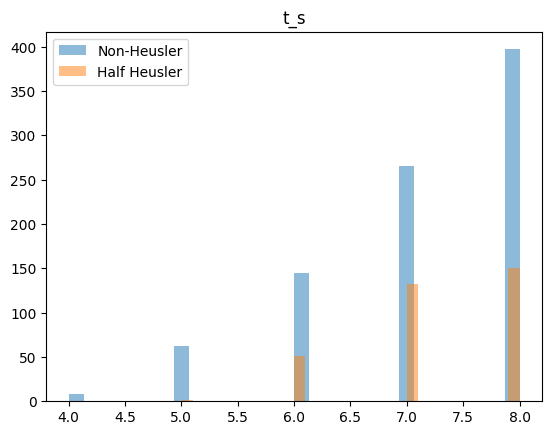

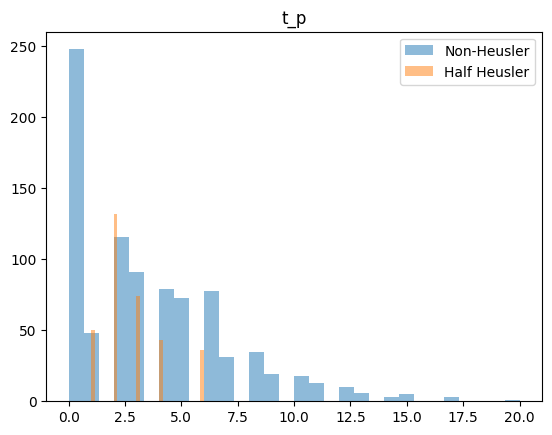

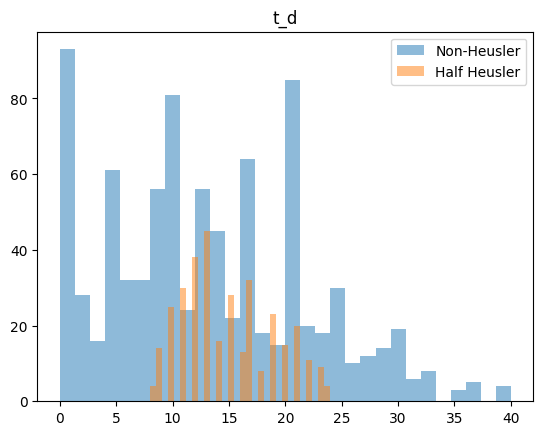

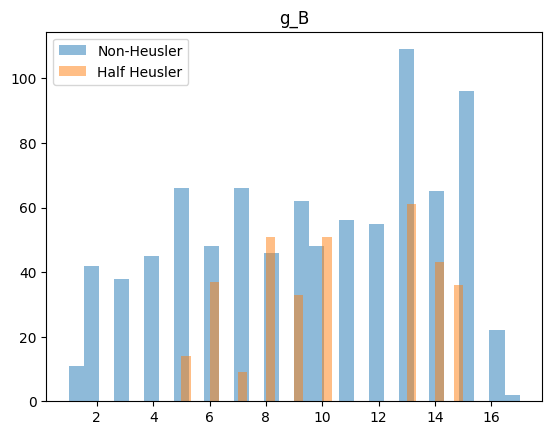

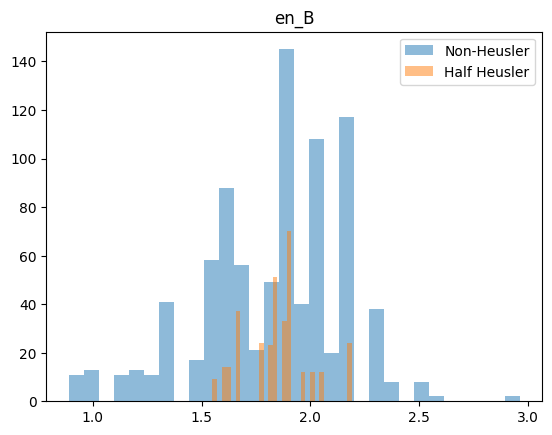

In [44]:
import matplotlib.pyplot as plt

for col in ['t_s', 't_p', 't_d', 'g_B', 'en_B']:
    plt.figure()
    plt.hist(
        df_final[df_final.choice==0][col],
        bins=30,
        alpha=0.5,
        label='Non-Heusler'
    )
    plt.hist(
        df_final[df_final.choice==1][col],
        bins=30,
        alpha=0.5,
        label='Half Heusler'
    )
    plt.title(col)
    plt.legend()
    plt.show()